In [1]:
import time
notebook_start = time.perf_counter()
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as ticker, sys, os, csv, shutil, json
from scipy.optimize import least_squares
from itertools import chain
from si_units import BAR, KELVIN
from pathlib import Path
from feos.eos import EquationOfState, PhaseDiagram
from feos.pcsaft import PcSaftParameters
from feos.eos.estimator import Estimator, Loss, DataSet, Phase
import io, base64

sys.path.append("..")
import PLOT_SETTINGS as ps

plot_dir = Path("PLOTS")
if plot_dir.exists():
    shutil.rmtree(plot_dir)
plot_dir.mkdir()

mixture = "CO-CH4"
PLOT    = False
npoints = 100       # for VLE calculations
nfit    = 1000
deg     = 2

In [2]:
def eos_from_kij(kij):
    """Returns equation of state (PC-SAFT) for current kij."""
    global parameters
    p = PcSaftParameters.new_binary(parameters.pure_records, kij)
    return EquationOfState.pcsaft(p)

def cost(kij, estimator):
    """Calculates cost function for current parameters."""
    return estimator.cost(eos_from_kij(kij))

def components(mixture):
    global comp1, comp2
    comp1, comp2 = mixture.split("-")
    
    return comp1, comp2

def poly_to_string(coeffs, var="T", name="k_ij"):
    """
    Build a readable polynomial string from np.polyfit coeffs.
    coeffs are in descending powers: [c_n, ..., c_1, c_0]
    """
    deg     = len(coeffs) - 1
    terms   = []
    for i, coef in enumerate(coeffs):
        power = deg - i
        if power == 0:
            terms.append(f"{coef:.6e}")
        elif power == 1:
            terms.append(f"({coef:.6e})*{var}")
        else:
            terms.append(f"({coef:.6e})*{var}^{power}")
    return f"{name}({var}) = " + " + ".join(terms)

def fit_kij_polynomial(df_best_kij, deg, T_col="Temperature_[K]", kij_col="kij"):
    """
    Fit kij(T) with a polynomial of degree 'deg'.

    Returns:
      coeffs  : np.ndarray of coefficients (descending powers)
      kij_func: np.poly1d callable function
    """
    T_data      = df_best_kij[T_col].to_numpy(dtype=float)
    kij_data    = df_best_kij[kij_col].to_numpy(dtype=float)

    # sort by temperature
    order       = np.argsort(T_data)
    T_data      = T_data[order]
    kij_data    = kij_data[order]

    coeffs      = np.polyfit(T_data, kij_data, deg=deg)
    kij_func    = np.poly1d(coeffs)

    print("\nFitted function:")
    print(poly_to_string(coeffs, var="T", name="k_ij"))
    print("\nnp.poly1d form:\n", kij_func)

    return coeffs, kij_func, T_data, kij_data

def set_custom_xlabel(ax, fontsize=ps.label_fontsize):
    ax.text(0.33, -0.17, r"$x_{\mathrm{N_2}}$",
        color="blue", fontsize=fontsize,transform=ax.transAxes, ha="right")
    ax.text(0.35, -0.17, r"$,$",
        color="black", fontsize=fontsize,transform=ax.transAxes, ha="center")
    ax.text(0.36, -0.17, r"$y_{\mathrm{N_2}}$",
        color="red", fontsize=fontsize,transform=ax.transAxes, ha="left")
    ax.text(0.49, -0.17, r"$/ \;[{\mathrm{mol} \; \mathrm{mol}^{-1}}]$",
        color="black", fontsize=fontsize,transform=ax.transAxes, ha="left")

def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

In [3]:
def VLE_PLOT(mixture, data, cols, temperature, kij):

    comp1, comp2    = components(mixture)
    isotherm        = data[data[cols["T"]] == temperature]
    
    if isotherm.empty:
        raise ValueError(f"No data available for T = {temperature} K")

    fig, ax = ps.plot_init()
    i = 0
 
    # Experimental data
    if isotherm[cols["Comp"]].iloc[0] == comp2:
        ax.plot(1-isotherm[cols["x1"]], isotherm[cols["P"]],
            color='blue', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markerfacecolor="#56abff", markeredgewidth=ps.markeredgewidth,
            label=isotherm.source.iloc[0] + f" (T = {temperature} K)")

        ax.plot(1-isotherm[cols["y1"]], isotherm[cols["P"]],
            color='red', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markerfacecolor="#FF5656", markeredgewidth=ps.markeredgewidth,)
    else:
        ax.plot(isotherm[cols["x1"]], isotherm[cols["P"]],
            color='blue', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize,markerfacecolor="#56abff", markeredgewidth=ps.markeredgewidth,
            label=isotherm.source.iloc[0] + f" (T = {temperature} K)")

        ax.plot(isotherm[cols["y1"]], isotherm[cols["P"]],
            color='red', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markerfacecolor="#FF5656", markeredgewidth=ps.markeredgewidth,)

    # PC-SAFT predictions
    vle = PhaseDiagram.binary_vle(eos_from_kij(kij),temperature * KELVIN, npoints)

    ax.plot(vle.vapor.molefracs[:, 1], vle.vapor.pressure / BAR,
        color='red', linewidth=ps.linewidth, linestyle="-",
        label=fr"PC-SAFT ($k_{{ij}} = {kij:.3f}$)")

    ax.plot(vle.liquid.molefracs[:, 1], vle.liquid.pressure / BAR,
        color='blue', linewidth=ps.linewidth, linestyle="-")

    ax.minorticks_on()
    ymax = (vle.liquid.pressure / BAR).max()
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    
    if ymax > 140:
        ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))
    else:
        ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))

    # ax.set_xlabel(r"$x_{\mathrm{CO_2}}$, $y_{\mathrm{CO_2}}$", fontsize=ps.label_fontsize)
    set_custom_xlabel(ax, fontsize=ps.label_fontsize)
    ax.set_ylabel(r"$P$ / [bar]", fontsize=ps.label_fontsize)
    ax.set_xlim(min(vle.vapor.molefracs[:, 1].min(), vle.liquid.molefracs[:, 1].min())- 0.1, 1.1)
    ax.set_ylim( (vle.liquid.pressure / BAR).min()/1.3, (vle.liquid.pressure / BAR).max() * 1.3)

    ps.style_legend(ax,loc='upper right',ncol=1,borderaxespad=1.0,frame=False)

    legend = ax.get_legend()
    for handle in legend.legend_handles:
        handle.set_color("black")
        handle.set_markerfacecolor("black")
        handle.set_markeredgecolor("black")
        
    ps.save_plot(fig, f"vle_T{int(temperature)}K_kij{kij:.3f}")


In [4]:
parameters  = PcSaftParameters.from_json(["methane", "carbon monoxide"], "../parameters_08.json")
pcsaft = EquationOfState.pcsaft(parameters)
parameters

|component|molarweight|$m$|$\sigma$|$\varepsilon$|$\mu$|$Q$|$\kappa_{AB}$|$\varepsilon_{AB}$|$N_A$|$N_B$|$N_C$|
|-|-|-|-|-|-|-|-|-|-|-|-|
|methane|16.031|1|3.70051|150.07147|-|-|-|-|0|0|0|
|carbon monoxide|27.995|1.32286|3.24532|91.17087|-|-|-|-|0|0|0|

In [5]:
data = pd.read_excel("VLE_CO_CH4.xlsx", sheet_name=0)
cols = {
        "P": data.columns[0],
        "x1": data.columns[1],
        "y1": data.columns[2],
        "T": data.columns[3],
        'Comp': data.columns[5]
        }

# data = data[~data[cols["T"]].between(252, 254)].reset_index(drop=True)
# print(data.tail())
# print(data.head())
comp1, comp2    = components(mixture)
print(f"Components: {comp1}, {comp2}")
print(data[cols["T"]].unique())

Components: CO, CH4
[123.4133 137.114  164.0136 178.0122]


In [6]:
data

,P_bar,x,y,T_K,source,x/y Composition
0,3.638,0.050,0.346,123.4133,"Christiansen, L. J.; Fredenslund, A.; Mollerup...",CO
1,5.005,0.119,0.542,123.4133,"Christiansen, L. J.; Fredenslund, A.; Mollerup...",CO
2,6.991,0.207,0.688,123.4133,"Christiansen, L. J.; Fredenslund, A.; Mollerup...",CO
3,9.879,0.360,0.800,123.4133,"Christiansen, L. J.; Fredenslund, A.; Mollerup...",CO
4,12.848,0.538,0.865,123.4133,"Christiansen, L. J.; Fredenslund, A.; Mollerup...",CO
5,15.878,0.721,0.916,123.4133,"Christiansen, L. J.; Fredenslund, A.; Mollerup...",CO
6,18.178,0.842,0.947,123.4133,"Christiansen, L. J.; Fredenslund, A.; Mollerup...",CO
7,20.245,0.926,0.975,123.4133,"Christiansen, L. J.; Fredenslund, A.; Mollerup...",CO
8,21.319,0.966,0.988,123.4133,"Christiansen, L. J.; Fredenslund, A.; Mollerup...",CO
9,6.991,0.040,0.206,137.1140,"Christiansen, L. J.; Fredenslund, A.; Mollerup...",CO


In [7]:
if PLOT == True:
    for T in data[cols["T"]].unique():
        VLE_PLOT(mixture, data, cols, T, 0)
        plt.show()

In [8]:
kij_distance = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [float(np.atleast_1d(fitted_kij)[0])]

    print(isotherm)
    
    if cols['Comp'] in isotherm.columns:
        if isotherm[cols['Comp']].iloc[0] == comp2:
            x = isotherm[cols["x1"]].to_numpy(float)
            y = isotherm[cols["y1"]].to_numpy(float)
        else:
            x = 1- isotherm[cols["x1"]].to_numpy(float)
            y = 1- isotherm[cols["y1"]].to_numpy(float)

    isotherms = [DataSet.binary_phase_diagram(T*KELVIN, isotherm[cols["P"]].values * BAR, x, y, npoints)]

    estimator = Estimator(isotherms, weights=[1], losses=[Loss.linear()])
    
    try:
        fitted_kij = least_squares(cost, initial_kij, bounds=[-0.5, 0.5], args=(estimator,), verbose=2).x
        kij_distance.append(float(np.atleast_1d(fitted_kij)[0]))
        kij_distance.append(kij_distance)
        mard_distance = estimator.mean_absolute_relative_difference(eos_from_kij(fitted_kij)) * 100
        mard_distance = mard_distance.mean()
        
    except Exception as e:
        print(f"Optimization failed for T = {T} K: {e}")
        fitted_kij = None
        mard_distance = np.nan
        
    kij_file = os.path.join("PLOTS", "kij_all.csv")
    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["distance", T, float(np.atleast_1d(fitted_kij)[0]) if fitted_kij is not None else np.nan,
         np.nan if np.isnan(mard_distance) else mard_distance])

if fitted_kij is not None:
    kij_val = float(np.atleast_1d(fitted_kij)[0])
    print(f"\033[1mOptimized kij value at T = {T} K: {kij_val:.6f}\033[0m")
    print(f"MARD (distance, k_ij = {kij_val:>6.4f}) = {mard_distance:>8.4f} %")
else:
    print(f"\033[1mOptimization failed at T = {T} K\033[0m")


    P_bar      x      y       T_K  \
0   3.638  0.050  0.346  123.4133   
1   5.005  0.119  0.542  123.4133   
2   6.991  0.207  0.688  123.4133   
3   9.879  0.360  0.800  123.4133   
4  12.848  0.538  0.865  123.4133   
5  15.878  0.721  0.916  123.4133   
6  18.178  0.842  0.947  123.4133   
7  20.245  0.926  0.975  123.4133   
8  21.319  0.966  0.988  123.4133   

                                              source x/y Composition   
0  Christiansen, L. J.; Fredenslund, A.; Mollerup...               CO  
1  Christiansen, L. J.; Fredenslund, A.; Mollerup...               CO  
2  Christiansen, L. J.; Fredenslund, A.; Mollerup...               CO  
3  Christiansen, L. J.; Fredenslund, A.; Mollerup...               CO  
4  Christiansen, L. J.; Fredenslund, A.; Mollerup...               CO  
5  Christiansen, L. J.; Fredenslund, A.; Mollerup...               CO  
6  Christiansen, L. J.; Fredenslund, A.; Mollerup...               CO  
7  Christiansen, L. J.; Fredenslund, A.; Mollerup... 

/tmp/ipykernel_32084/595534521.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)
/tmp/ipykernel_32084/595534521.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.6412e-07                                    8.21e-06    
       1              2         1.5256e-07      1.16e-08       1.33e-03       4.86e-07    
       2              3         1.5252e-07      3.84e-11       7.95e-05       7.91e-09    
`gtol` termination condition is satisfied.
Function evaluations 3, initial cost 1.6412e-07, final cost 1.5252e-07, first-order optimality 7.91e-09.
     P_bar      x      y       T_K  \
19  20.903  0.033  0.104  164.0136   
20  23.436  0.072  0.197  164.0136   
21  26.415  0.120  0.281  164.0136   
22  31.938  0.212  0.389  164.0136   
23  37.207  0.294  0.460  164.0136   
24  41.594  0.361  0.499  164.0136   
25  45.576  0.429  0.518  164.0136   
26  46.609  0.452  0.510  164.0136   

                                               source x/y Composition   
19  Christiansen, L. J.; Fredenslund, A.; Mollerup...               CO  

/tmp/ipykernel_32084/595534521.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)
/tmp/ipykernel_32084/595534521.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)


     P_bar      x      y       T_K  \
27  33.012  0.026  0.059  178.0122   
28  36.072  0.062  0.125  178.0122   
29  38.848  0.096  0.176  178.0122   
30  42.263  0.139  0.223  178.0122   
31  45.505  0.184  0.252  178.0122   
32  47.390  0.213  0.261  178.0122   

                                               source x/y Composition   
27  Christiansen, L. J.; Fredenslund, A.; Mollerup...               CO  
28  Christiansen, L. J.; Fredenslund, A.; Mollerup...               CO  
29  Christiansen, L. J.; Fredenslund, A.; Mollerup...               CO  
30  Christiansen, L. J.; Fredenslund, A.; Mollerup...               CO  
31  Christiansen, L. J.; Fredenslund, A.; Mollerup...               CO  
32  Christiansen, L. J.; Fredenslund, A.; Mollerup...               CO  
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.9226e-07                                    7.60e-06    
       1              2         1.7657e-

In [9]:
if PLOT == True:
    for T, kij in zip(data[cols["T"]].unique(), kij_distance):
        VLE_PLOT(mixture, data, cols, T, kij)
        plt.show()

In [10]:
kij_mu = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [fitted_kij[0]]
    
    if cols['Comp'] in isotherm.columns:
        if isotherm[cols['Comp']].iloc[0] == comp2:
            x = isotherm[cols["x1"]].to_numpy(float)
            y = isotherm[cols["y1"]].to_numpy(float)
        else:
            x = 1- isotherm[cols["x1"]].to_numpy(float)
            y = 1- isotherm[cols["y1"]].to_numpy(float)
    
    isotherms = [DataSet.binary_vle_chemical_potential(np.array([T]*len(isotherm)) *KELVIN, 
        isotherm[cols["P"]].values * BAR, x, y)]

    estimator_mu = Estimator(isotherms, weights=[1]*3, losses=[Loss.linear()]*3)

    fitted_kij_mu = least_squares(cost, initial_kij, bounds=[-0.5, 0.5], args=(estimator_mu,), verbose=2).x

    kij_mu.append(fitted_kij_mu[0])

    mard_mu = estimator_mu.mean_absolute_relative_difference(eos_from_kij(fitted_kij_mu)) * 100

    kij_file = os.path.join("PLOTS", "kij_all.csv")

    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["chemical potential", T, fitted_kij_mu[0], mard_mu.mean()])

    print(f"\033[1mOptimized kij value at T = {T} K: {fitted_kij_mu[0]:.6f}\033[0m")
    print(f"MARD (chem. pot., k_ij = {fitted_kij_mu[0]:>6.4}) = {mard_mu.mean():>8.4} %")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.6528e-07                                    1.71e-05    
       1              2         9.6126e-08      6.92e-08       3.93e-03       1.38e-07    
       2              3         9.6121e-08      4.60e-12       3.24e-05       9.27e-11    
`gtol` termination condition is satisfied.
Function evaluations 3, initial cost 1.6528e-07, final cost 9.6121e-08, first-order optimality 9.27e-11.
Optimized kij value at T = 123.4133 K: 0.015380
MARD (chem. pot., k_ij = 0.01538) =   0.3604 %
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.3325e-07                                    1.15e-05    
       1              2         8.1842e-08      5.14e-08       4.53e-03       9.51e-08    
       2              3         8.1838e-08      3.58e-12       3.84e-05       4.48e-10    
`gtol` termination condition 

/tmp/ipykernel_32084/595534521.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)


In [11]:
if PLOT == True:
    for T, kij in zip(data[cols["T"]].unique(), kij_mu):
        VLE_PLOT(mixture, data, cols, T, kij)
        plt.show()

In [12]:
kij_pressure = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [fitted_kij[0]]
        
    if cols['Comp'] in isotherm.columns:
        if isotherm[cols['Comp']].iloc[0] == comp2:
            x = isotherm[cols["x1"]].to_numpy(float)
            y = isotherm[cols["y1"]].to_numpy(float)
        else:
            x = 1- isotherm[cols["x1"]].to_numpy(float)
            y = 1- isotherm[cols["y1"]].to_numpy(float)

    isotherms = [[DataSet.binary_vle_pressure(np.array([T]*len(isotherm))*KELVIN, 
                isotherm[cols["P"]].values * BAR, x,Phase.Liquid)],]
    
    estimator_p = Estimator(list(chain.from_iterable(isotherms)), weights=[1]*6, losses=[Loss.linear()]*6)
    
    try:
        res = least_squares(cost, initial_kij, bounds=(-1, 1), args=(estimator_p,), verbose=2)

        kij_value = float(np.atleast_1d(res.x)[0])
        kij_pressure.append(kij_value)

        mard_value = float(estimator_p.mean_absolute_relative_difference(
            eos_from_kij(np.array([kij_value]))) * 100)

    except Exception as e:
        print("Optimization failed:", e)
        kij_value = np.nan
        kij_pressure.append(np.nan)
        mard_value = np.nan
    
    kij_file = os.path.join("PLOTS", "kij_all.csv")

    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["pressure", T, kij_value, mard_value])

    print(f"\033[1mOptimized kij value at T = {T} K: {kij_value:.6f}\033[0m")
    print(f"MARD (pressure,   k_ij = {kij_value:>6.4}) = {mard_value:>8.4} %")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.1536e-07                                    7.17e-05    
       1              2         2.4304e-07      7.23e-08       2.00e-03       5.81e-07    
       2              3         2.4304e-07      4.39e-12       1.53e-05       1.12e-09    
`gtol` termination condition is satisfied.
Function evaluations 3, initial cost 3.1536e-07, final cost 2.4304e-07, first-order optimality 1.12e-09.
Optimized kij value at T = 123.4133 K: 0.013394
MARD (pressure,   k_ij = 0.01339) =    1.027 %
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.9735e-07                                    3.50e-05    
       1              2         2.6858e-07      2.88e-08       1.67e-03       2.78e-08    
       2              3         2.6858e-07      1.93e-14       1.39e-06       2.10e-10    
`gtol` termination condition 

/tmp/ipykernel_32084/595534521.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)
/tmp/ipykernel_32084/2049560164.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mard_value = float(estimator_p.mean_absolute_relative_difference(


In [13]:
if PLOT == True:
    for T, kij in zip(data[cols["T"]].unique(), kij_pressure):
        try:
            VLE_PLOT(mixture, data, cols, T, kij)
            plt.show()
        except Exception as e:
            print(f"Error plotting VLE for T={T} K and kij={kij}: {e}")
            plt.close()
            continue

In [14]:
## KIJ Interpolation/Extrapolation
df_KIJ      = pd.read_csv("PLOTS/kij_all.csv")

# To take the minimum MARD for each temperature, regardless of optimization type
idx         = df_KIJ.groupby("Temperature_[K]")["MARD_percentage"].idxmin()
df_best_kij = df_KIJ.loc[idx].reset_index(drop=True)
T_min       = df_best_kij["Temperature_[K]"].min()
T_max       = df_best_kij["Temperature_[K]"].max()
kij_mean    = float(df_best_kij["kij"].mean())
kij_std     = float(df_best_kij["kij"].std(ddof=1))

# Choosing kij based on the distance optimization type, as it is more consistent across temperatures and has lower MARD values compared to chemical potential and pressure optimizations
# df_best_kij = (df_KIJ[df_KIJ["Optimization type"] == "distance"].sort_values("Temperature_[K]").reset_index(drop=True))
print(df_best_kij)

coeffs_lin,  kij_func_lin,  T_data, kij_data = fit_kij_polynomial(df_best_kij, deg=1)
coeffs_quad, kij_func_quad, T_data, kij_data = fit_kij_polynomial(df_best_kij, deg=2)

    Optimization type  Temperature_[K]       kij  MARD_percentage
0            distance         123.4133  0.013061         0.218282
1            distance         137.1140  0.011655         0.269320
2  chemical potential         164.0136  0.005996         0.385526
3  chemical potential         178.0122  0.019865         0.224629

Fitted function:
k_ij(T) = (5.980671e-05)*T + 3.635064e-03

np.poly1d form:
  
5.981e-05 x + 0.003635

Fitted function:
k_ij(T) = (1.360858e-05)*T^2 + (-4.041991e-03)*T + 3.064166e-01

np.poly1d form:
            2
1.361e-05 x - 0.004042 x + 0.3064


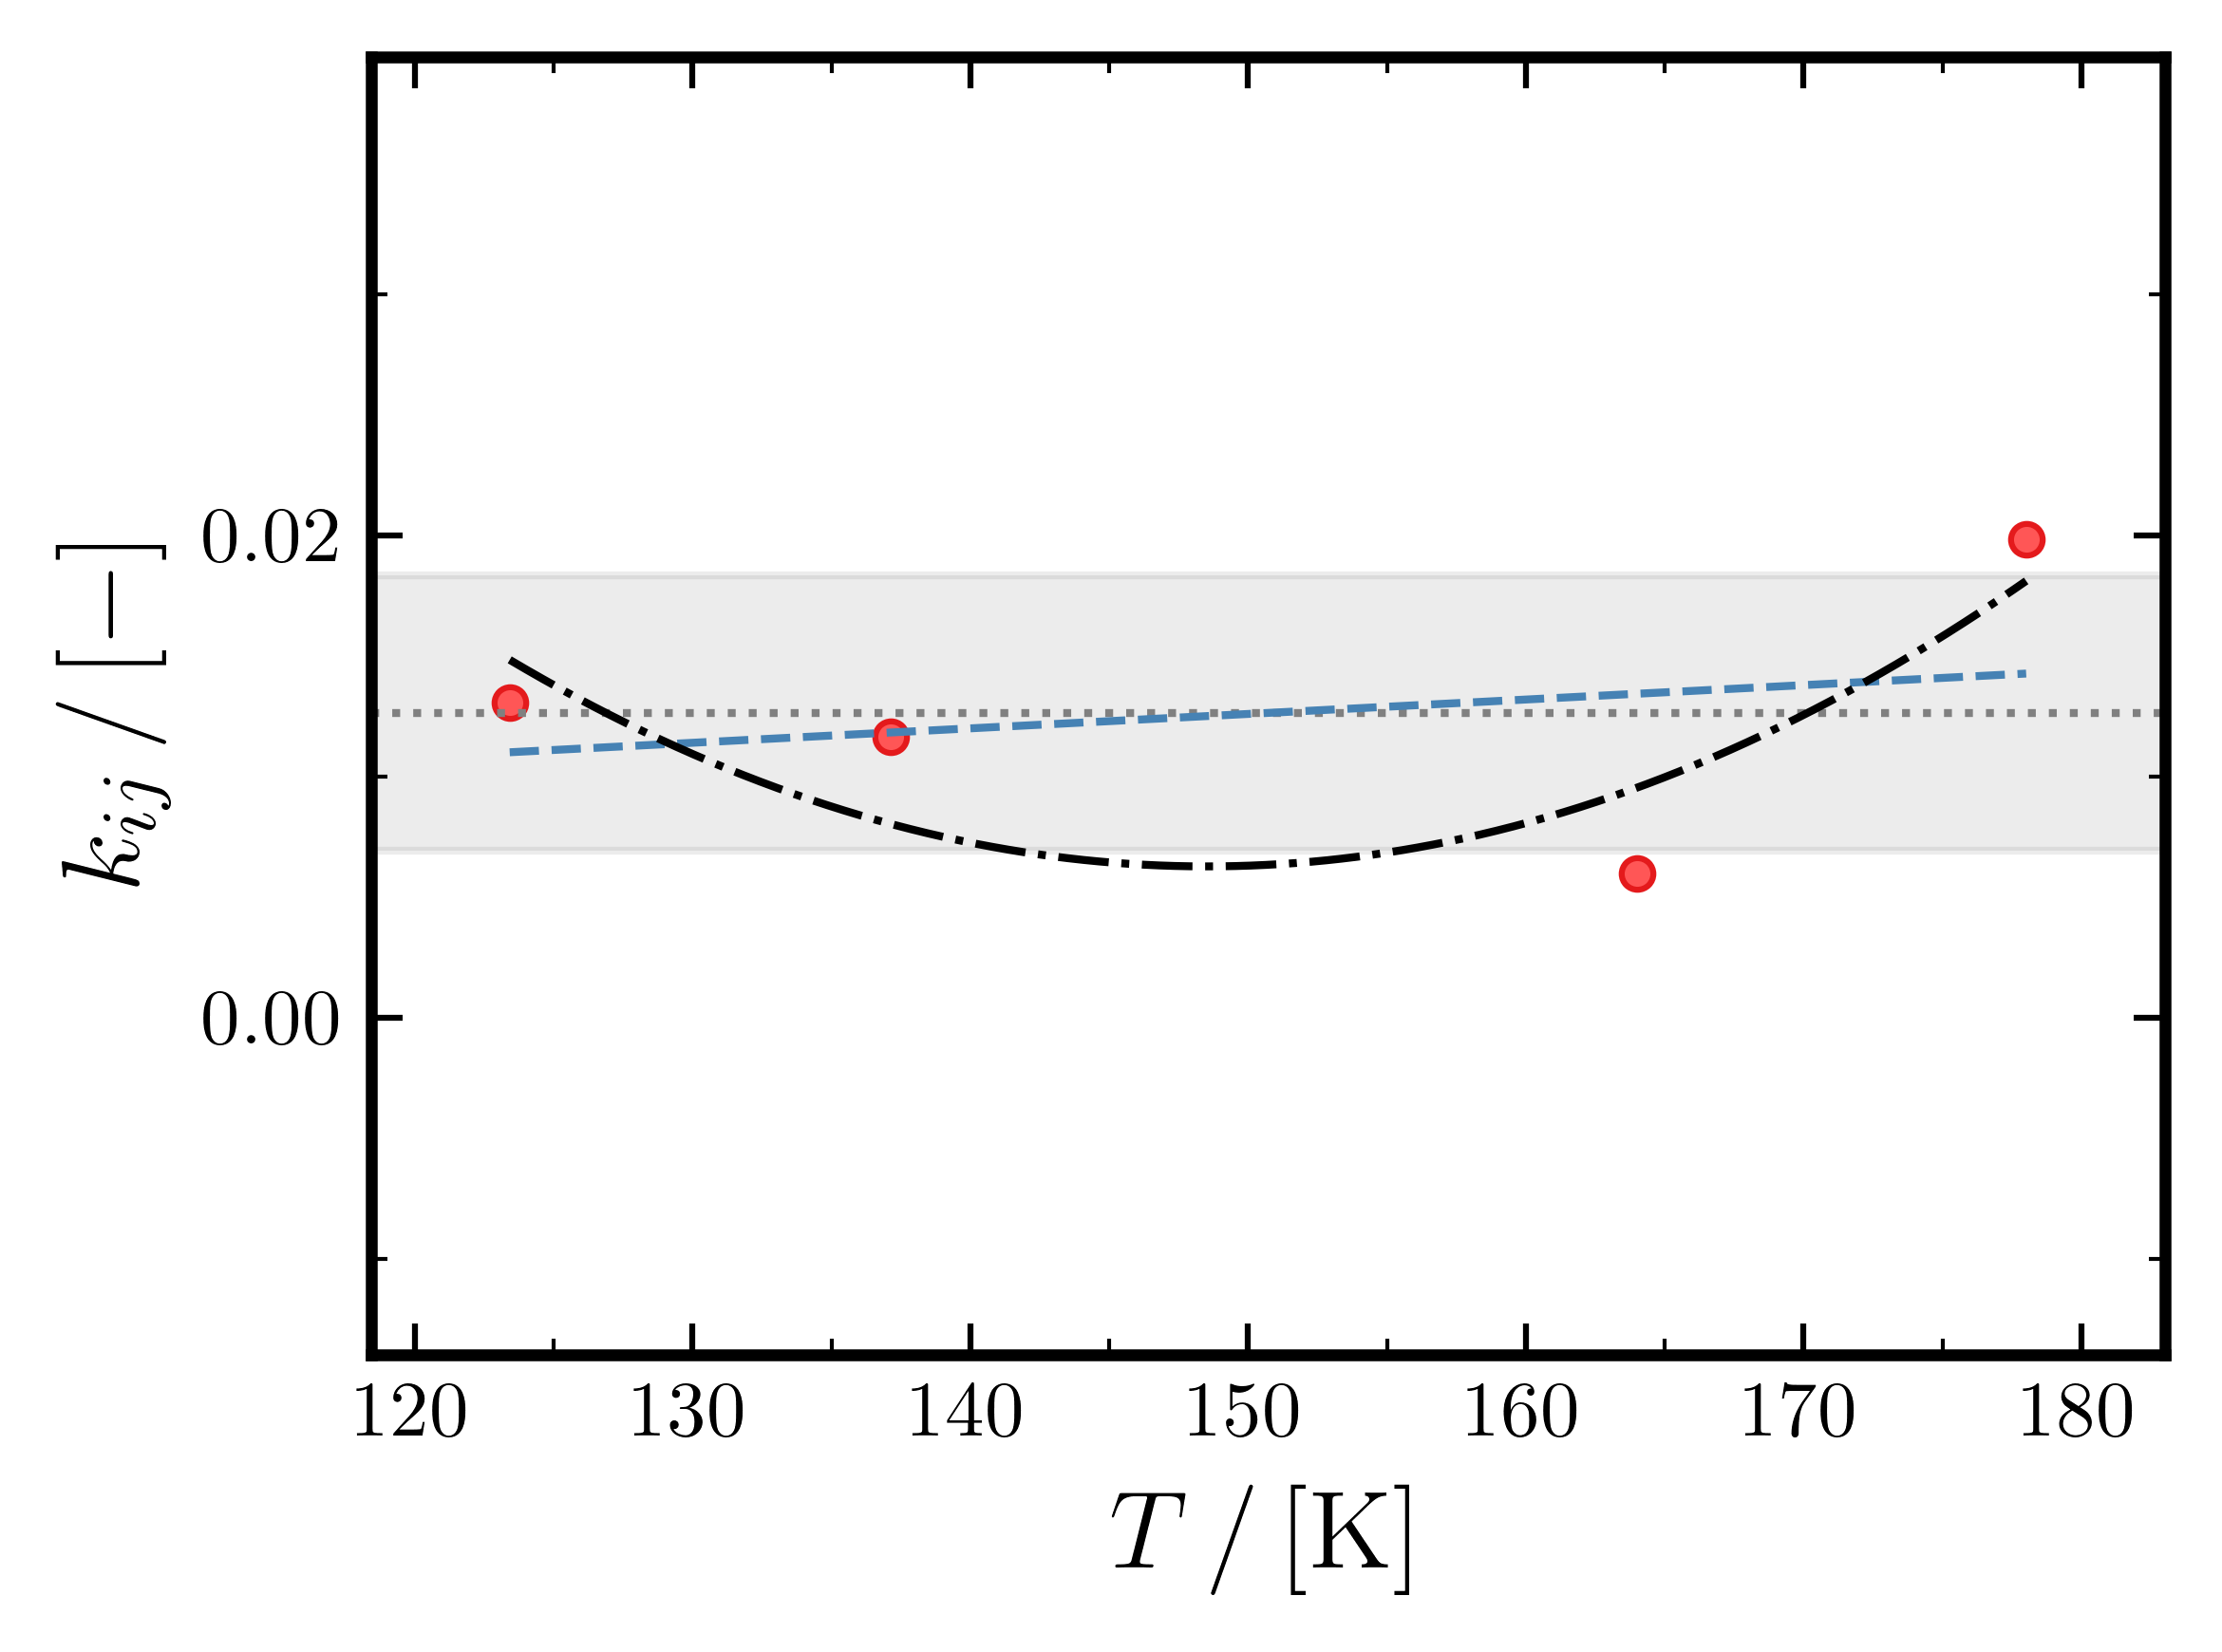

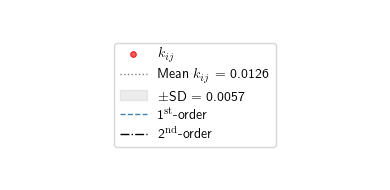

In [15]:
T_fit           = np.linspace(T_data.min(), T_data.max(), nfit)
kij_fit_lin     = kij_func_lin(T_fit)
kij_fit_quad    = kij_func_quad(T_fit)

fig1, ax1 = ps.plot_init()

ax1.plot(df_best_kij["Temperature_[K]"], df_best_kij["kij"],linestyle="",
    linewidth=ps.linewidth,marker=ps.markers[0],markersize=ps.markersize, markerfacecolor="#FF5656",
    markeredgewidth=ps.markeredgewidth,color=ps.colors[0],
    label=r"$k_{ij}$")

# Constant: mean and SD as horizontal band
ax1.axhline(kij_mean, color="gray", linewidth=ps.linewidth, linestyle=":",
    label=rf"Mean $k_{{ij}}$ = {kij_mean:.4f}")
ax1.axhspan(kij_mean - kij_std, kij_mean + kij_std,
    alpha=0.15, color="gray",
    label=rf"$\pm$SD = {kij_std:.4f}")

# Linear fit
ax1.plot(T_fit, kij_fit_lin, color="steelblue", linewidth=ps.linewidth, linestyle="--",
    label=r"1$^{\mathrm{st}}$-order")

# Quadratic fit
ax1.plot(T_fit, kij_fit_quad, color="k", linewidth=ps.linewidth, linestyle="-.",
    label=r"2$^{\mathrm{nd}}$-order")
    
ax1.set_xlabel(r"$T\,/\, \mathrm{[K]}$", fontsize=ps.label_fontsize)
ax1.set_ylabel(r"$k_{ij}\, / \, [-]$", fontsize=ps.label_fontsize)
# ps.style_legend(ax1, loc='lower left', ncol=1, borderaxespad=1.0, frame=True)

ax1.minorticks_on()
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax1.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax1.xaxis.set_minor_locator(ticker.MultipleLocator(5))

ax1.set_xlim(T_data.min() - 5, T_data.max() + 5)
ax1.set_ylim(kij_data.min() - 0.02, kij_data.max() + 0.02)

fig1.tight_layout()
ps.save_plot(fig1, f"kij_{mixture.replace('-','-')}_vs_T")
plt.show()

# Separate legend figure
handles, labels = ax1.get_legend_handles_labels()
fig_leg, ax_leg = plt.subplots(figsize=(4, 2))
ax_leg.axis("off")
ax_leg.legend(handles, labels, loc="center", ncol=1, frameon=True)
fig_leg.tight_layout()
ps.save_plot(fig_leg, f"kij_{mixture.replace('-', '-')}_legend")
plt.show()

In [16]:
out = {
    "T_min": T_min,
    "T_max": T_max,
    "constant": {
        "deg"   : 0,
        "mean"  : kij_mean,
        "std"   : kij_std
    },
    "linear": {
        "deg"   : 1,
        "coeffs": [float(c) for c in coeffs_lin]
    },
    "quadratic": {
        "deg"   : 2,
        "coeffs": [float(c) for c in coeffs_quad]
    },
    "plots": {
        "kij_vs_T" : fig_to_b64(fig1),
        "legend"   : fig_to_b64(fig_leg)
    }
}

Path("KIJ.json").write_text(json.dumps(out, indent=2), encoding="utf-8")

36664

In [17]:
notebook_end = time.perf_counter()
print(f"Total notebook runtime: {notebook_end - notebook_start:.2f} s")

Total notebook runtime: 8.71 s
